In [2]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Load dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"
column_names = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'class']
df = pd.read_csv(url, header=None, names=column_names)

# Normalize numerical features
scaler = StandardScaler()
features = df.drop('class', axis=1)
scaled_features = scaler.fit_transform(features)

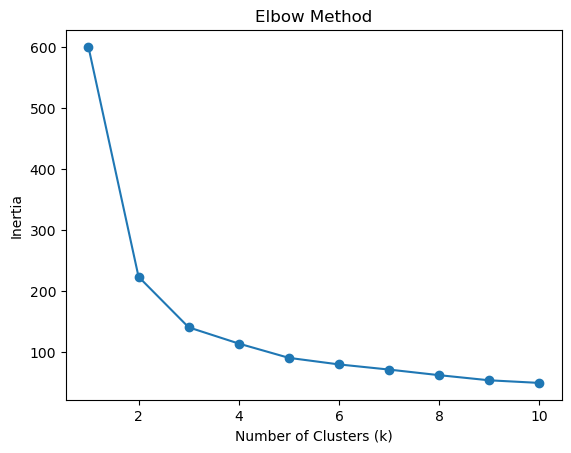

In [6]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia=[]

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42,n_init=10)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

# Plot elbow curve
plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

kmeans = KMeans(n_clusters=3, random_state=42,n_init=10)
kmeans_labels = kmeans.fit_predict(scaled_features)

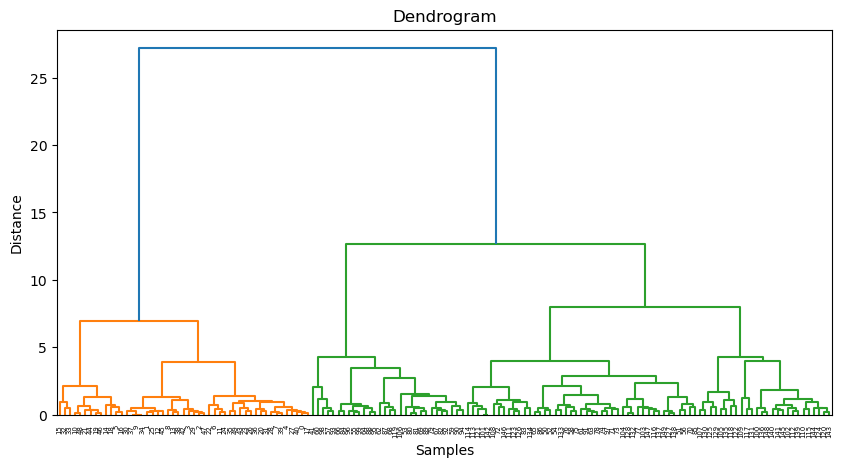

In [9]:
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering

# Dendrogram
plt.figure(figsize=(10, 5))
dendrogram = sch.dendrogram(sch.linkage(scaled_features, method='ward'))
plt.title('Dendrogram')
plt.xlabel('Samples')
plt.ylabel('Distance')
plt.show()

# Fit Agglomerative Clustering
hc = AgglomerativeClustering(n_clusters=3)
hc_labels = hc.fit_predict(scaled_features)


In [10]:
from sklearn.metrics import silhouette_score

# Silhouette Score
silhouette_kmeans = silhouette_score(scaled_features, kmeans_labels)
silhouette_hc = silhouette_score(scaled_features, hc_labels)

print("KMeans Silhouette Score:", silhouette_kmeans)
print("Hierarchical Clustering Silhouette Score:", silhouette_hc)

KMeans Silhouette Score: 0.45897178670187166
Hierarchical Clustering Silhouette Score: 0.44553956399200406


In [11]:
for r in [0, 21, 42, 100]:
    kmeans = KMeans(n_clusters=3, random_state=r)
    labels = kmeans.fit_predict(scaled_features)
    print(f"Random State {r} -> Silhouette Score: {silhouette_score(scaled_features, labels):.3f}")


Random State 0 -> Silhouette Score: 0.459
Random State 21 -> Silhouette Score: 0.459
Random State 42 -> Silhouette Score: 0.459
Random State 100 -> Silhouette Score: 0.459


/opt/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


In [12]:
from sklearn.metrics import adjusted_rand_score

true_labels = df['class'].astype('category').cat.codes
ari_kmeans = adjusted_rand_score(true_labels, kmeans_labels)
ari_hc = adjusted_rand_score(true_labels, hc_labels)

print("Adjusted Rand Index (KMeans):", ari_kmeans)
print("Adjusted Rand Index (HC):", ari_hc)


Adjusted Rand Index (KMeans): 0.6201351808870379
Adjusted Rand Index (HC): 0.6153229932145449


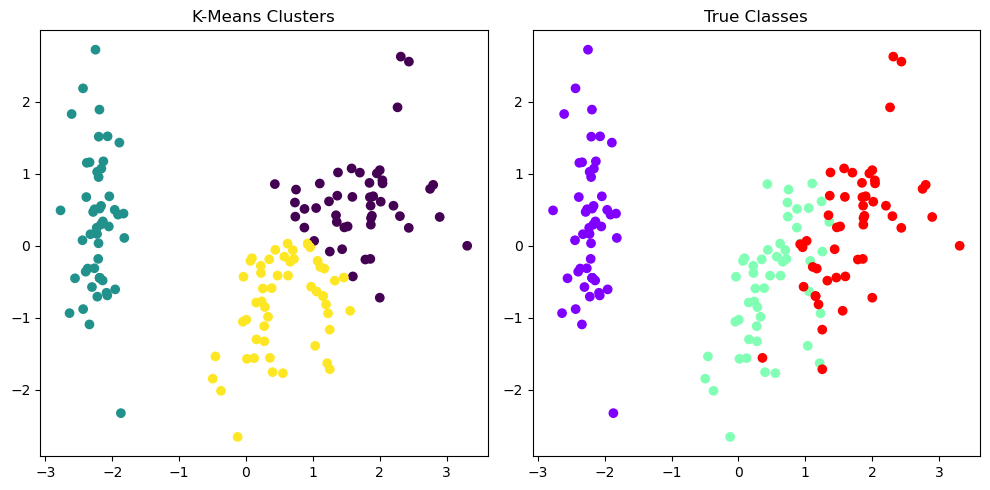

In [13]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
reduced = pca.fit_transform(scaled_features)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.scatter(reduced[:, 0], reduced[:, 1], c=kmeans_labels, cmap='viridis')
plt.title("K-Means Clusters")

plt.subplot(1, 2, 2)
plt.scatter(reduced[:, 0], reduced[:, 1], c=true_labels, cmap='rainbow')
plt.title("True Classes")

plt.tight_layout()
plt.show()
